# Lab-6: Implementation of Sparse Autoencoder for Feature Representation

## Reg No: 2548514

### 1) Import Libraries:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 2) Data Preprocessing:

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)


### 3) Sparse Autoencoder Model:

In [ ]:
class SparseAutoencoder(nn.Module):

    def __init__(self):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 3072),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded


model = SparseAutoencoder().to(device)


### 4) Sparsity Penalty Function:

In [ ]:
def sparsity_penalty(encoded, rho=0.05, beta=1):

    rho_hat = torch.mean(encoded, dim=0)

    kl_div = rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return beta * torch.sum(kl_div)


### 5) Loss and Optimizer:

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20


### 6) Training Loop:

In [ ]:
for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, outputs = model(images)

        recon_loss = criterion(outputs, images)

        sparse_loss = sparsity_penalty(encoded)

        loss = recon_loss + sparse_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/20], Loss: inf
Epoch [2/20], Loss: 0.2288
Epoch [3/20], Loss: 0.2141
Epoch [4/20], Loss: 0.2034
Epoch [5/20], Loss: 0.1970
Epoch [6/20], Loss: 0.1924
Epoch [7/20], Loss: 0.1896
Epoch [8/20], Loss: 0.1874
Epoch [9/20], Loss: 0.1856
Epoch [10/20], Loss: 0.1843
Epoch [11/20], Loss: 0.1832
Epoch [12/20], Loss: 0.1822
Epoch [13/20], Loss: 0.1817
Epoch [14/20], Loss: 0.1811
Epoch [15/20], Loss: 0.1809
Epoch [16/20], Loss: 0.1804
Epoch [17/20], Loss: 0.1800
Epoch [18/20], Loss: 0.1800
Epoch [19/20], Loss: 0.1796
Epoch [20/20], Loss: 0.1791


### 7) Evaluation:

In [ ]:
test_loss = 0

with torch.no_grad():

    for images, _ in test_loader:

        images = images.view(images.size(0), -1).to(device)

        encoded, outputs = model(images)

        loss = criterion(outputs, images)

        test_loss += loss.item()

print("Test Reconstruction Loss:", test_loss/len(test_loader))


Test Reconstruction Loss: 0.17534716880019707


### 8) Visualization:

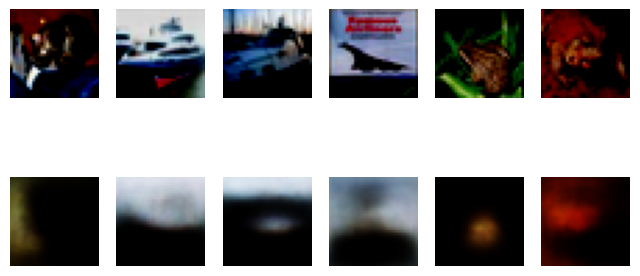

In [ ]:
dataiter = iter(test_loader)
images, _ = next(dataiter)

images = images.view(images.size(0), -1).to(device)

with torch.no_grad():
    _, recon = model(images)

images = images.view(-1,3,32,32).cpu()
recon = recon.view(-1,3,32,32).cpu()

plt.figure(figsize=(8,4))

for i in range(6):

    # Original
    plt.subplot(2,6,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis('off')

    # Reconstruction
    plt.subplot(2,6,i+7)
    plt.imshow(recon[i].permute(1,2,0))
    plt.axis('off')

plt.show()